In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("Dataset\Application_Data.csv")

In [5]:
df.shape

(25128, 21)

In [7]:
df.columns

Index(['Applicant_ID', 'Applicant_Gender', 'Owned_Car', 'Owned_Realty',
       'Total_Children', 'Total_Income', 'Income_Type', 'Education_Type',
       'Family_Status', 'Housing_Type', 'Owned_Mobile_Phone',
       'Owned_Work_Phone', 'Owned_Phone', 'Owned_Email', 'Job_Title',
       'Total_Family_Members', 'Applicant_Age', 'Years_of_Working',
       'Total_Bad_Debt', 'Total_Good_Debt', 'Status'],
      dtype='object')

In [8]:
df.dtypes

Applicant_ID             int64
Applicant_Gender        object
Owned_Car                int64
Owned_Realty             int64
Total_Children           int64
Total_Income             int64
Income_Type             object
Education_Type          object
Family_Status           object
Housing_Type            object
Owned_Mobile_Phone       int64
Owned_Work_Phone         int64
Owned_Phone              int64
Owned_Email              int64
Job_Title               object
Total_Family_Members     int64
Applicant_Age            int64
Years_of_Working         int64
Total_Bad_Debt           int64
Total_Good_Debt          int64
Status                   int64
dtype: object

In [19]:
missing=df.isnull().sum()

In [20]:
missing_pct = (missing / len(df) * 100).round(2)
missing_pct

Applicant_ID            0.0
Applicant_Gender        0.0
Owned_Car               0.0
Owned_Realty            0.0
Total_Children          0.0
Total_Income            0.0
Income_Type             0.0
Education_Type          0.0
Family_Status           0.0
Housing_Type            0.0
Owned_Mobile_Phone      0.0
Owned_Work_Phone        0.0
Owned_Phone             0.0
Owned_Email             0.0
Job_Title               0.0
Total_Family_Members    0.0
Applicant_Age           0.0
Years_of_Working        0.0
Total_Bad_Debt          0.0
Total_Good_Debt         0.0
Status                  0.0
dtype: float64

In [22]:
binary_candidates = ['Owned_Car','Owned_Realty','Owned_Mobile_Phone','Owned_Work_Phone','Owned_Phone','Owned_Email','Status']
for c in binary_candidates:
    if c in df_clean.columns:
        df_clean[c] = pd.to_numeric(df_clean[c], errors='coerce').fillna(0).astype(int)

In [23]:
for c in ['Applicant_Age','Total_Income','Years_of_Working','Total_Children','Total_Family_Members','Total_Bad_Debt','Total_Good_Debt']:
    if c in df_clean.columns:
        df_clean[c] = pd.to_numeric(df_clean[c], errors='coerce').fillna(df_clean[c].median())

In [25]:
if 'Applicant_ID' in df_clean.columns:
    before = len(df_clean)
    df_clean = df_clean.drop_duplicates(subset=['Applicant_ID'], keep='first')
    after = len(df_clean)
    print("removed duplicate rows based on applicant_id:", before-after)
else:
    print("no applicant_id column found — skipping duplicate-removal by key")


removed duplicate rows based on applicant_id: 0


In [26]:
def normalize_text_col(s):
    return s.astype(str).str.strip().replace({'nan':'Unknown','None':'Unknown'})

for c in df_clean.select_dtypes(include=['object','category']).columns:
    df_clean[c] = normalize_text_col(df_clean[c])

# Gender normalization
if 'Applicant_Gender' in df_clean.columns:
    df_clean['Applicant_Gender'] = df_clean['Applicant_Gender'].str.upper().str.strip().replace({
        'M':'Male','MALE':'Male','MALE.':'Male',
        'F':'Female','FEMALE':'Female','FEMALE.':'Female',
        '0':'Unknown','1':'Unknown'
    })


In [28]:
df_clean.head()

,Applicant_ID,Applicant_Gender,Owned_Car,Owned_Realty,Total_Children,Total_Income,Income_Type,Education_Type,Family_Status,Housing_Type,...,Owned_Work_Phone,Owned_Phone,Owned_Email,Job_Title,Total_Family_Members,Applicant_Age,Years_of_Working,Total_Bad_Debt,Total_Good_Debt,Status
0,5008806,Male,1,1,0,112500,Working,Secondary / secondary special,Married,House / apartment,...,0,0,0,Security staff,2,59,4,0,30,1
1,5008808,Female,0,1,0,270000,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,0,1,1,Sales staff,1,53,9,0,5,1
2,5008809,Female,0,1,0,270000,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,0,1,1,Sales staff,1,53,9,0,5,1
3,5008810,Female,0,1,0,270000,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,0,1,1,Sales staff,1,53,9,0,27,1
4,5008811,Female,0,1,0,270000,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,0,1,1,Sales staff,1,53,9,0,39,1


In [29]:
def iqr_cap(col):
    q1 = col.quantile(0.25)
    q3 = col.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    return col.clip(lower=lower, upper=upper)

numeric_cols_for_outlier = [c for c in df_clean.select_dtypes(include=[np.number]).columns if df_clean[c].nunique() > 5]
for c in numeric_cols_for_outlier:
    df_clean[c] = iqr_cap(df_clean[c])

print("Applied IQR capping to:", numeric_cols_for_outlier)


Applied IQR capping to: ['Applicant_ID', 'Total_Children', 'Total_Income', 'Total_Family_Members', 'Applicant_Age', 'Years_of_Working', 'Total_Bad_Debt', 'Total_Good_Debt']


C:\Users\abdul\AppData\Local\Temp\ipykernel_22752\553015311.py:13: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.subplots(figsize=(6,3))


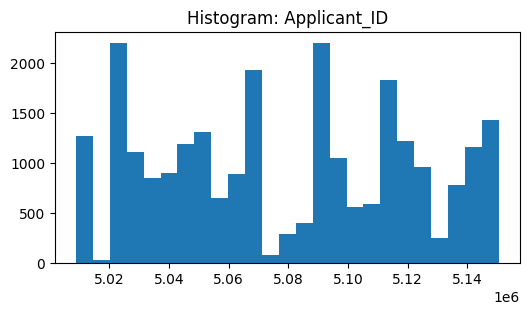

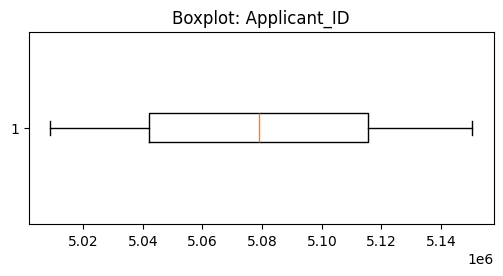

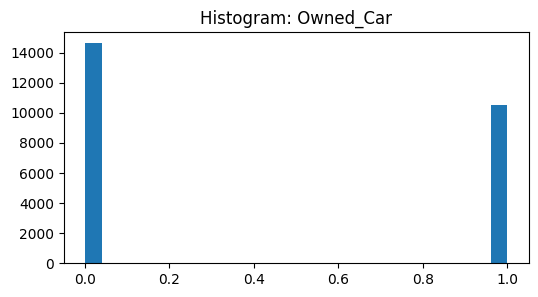

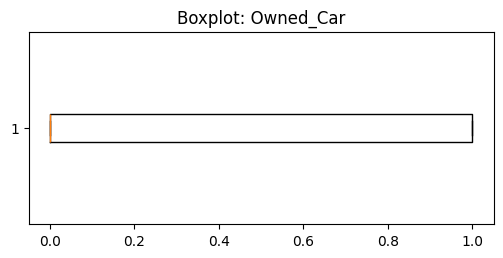

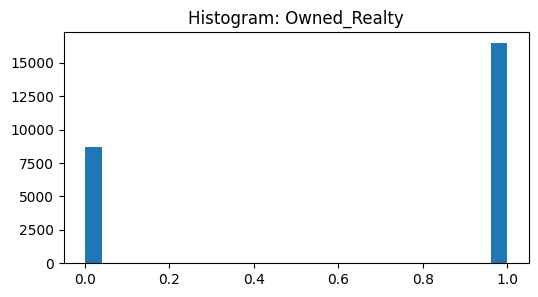

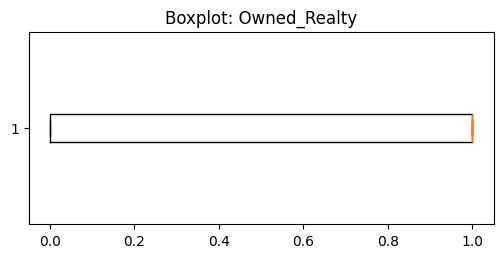

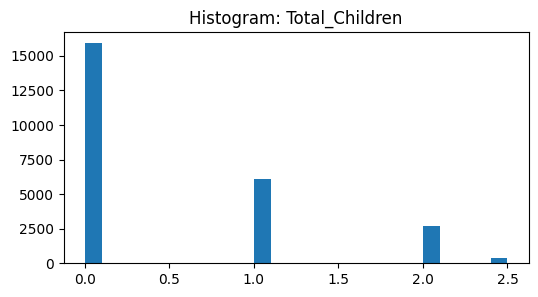

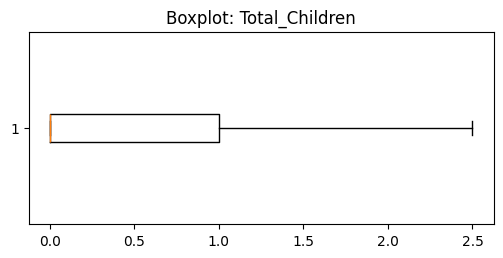

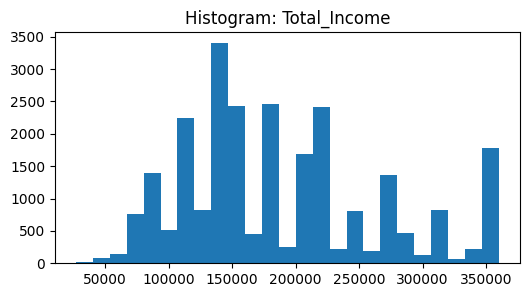

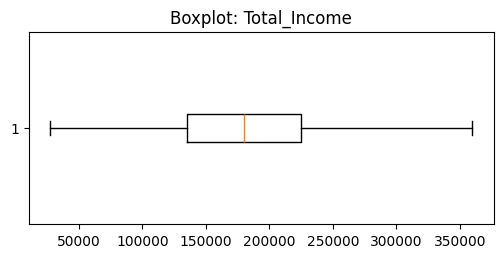

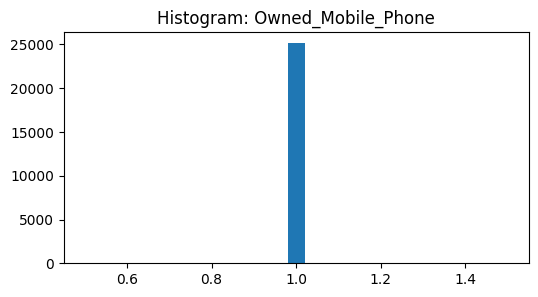

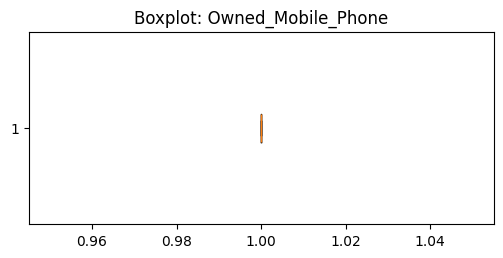

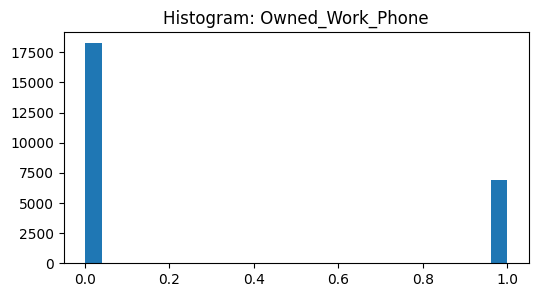

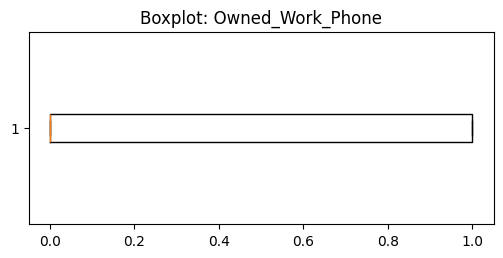

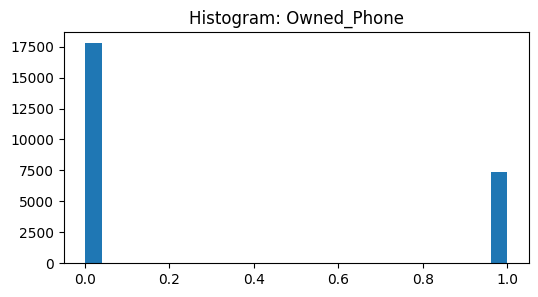

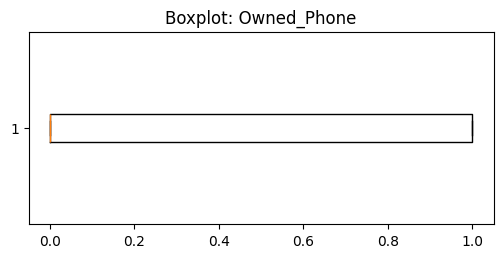

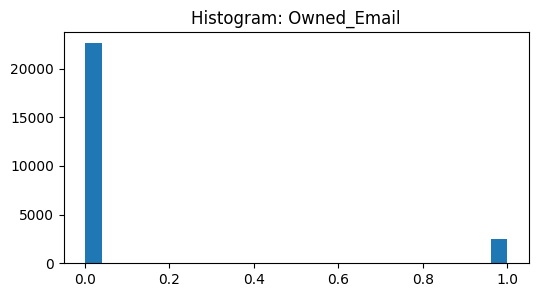

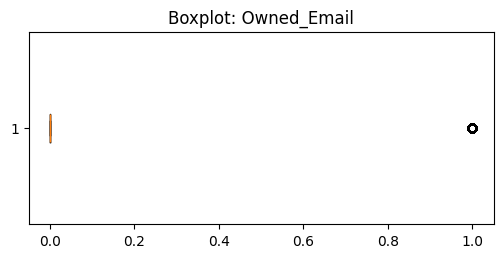

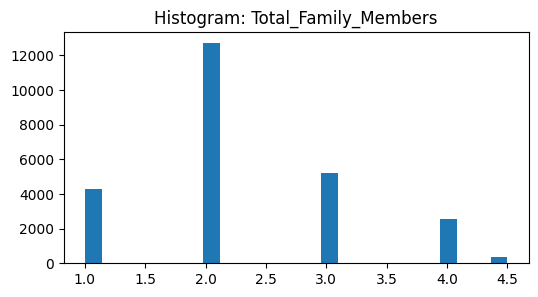

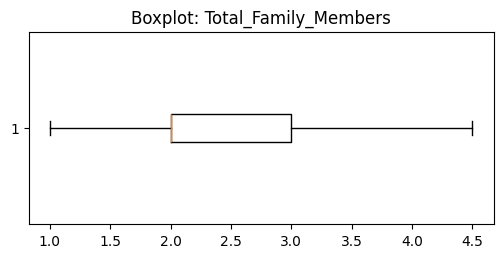

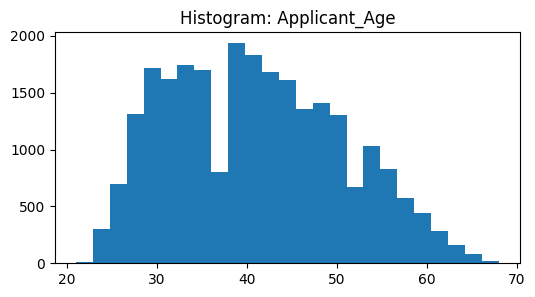

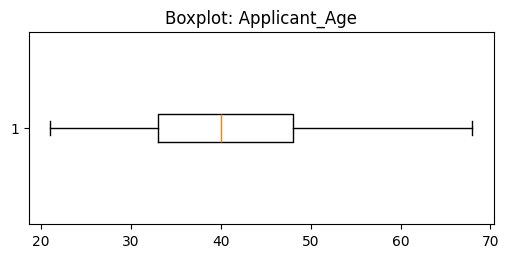

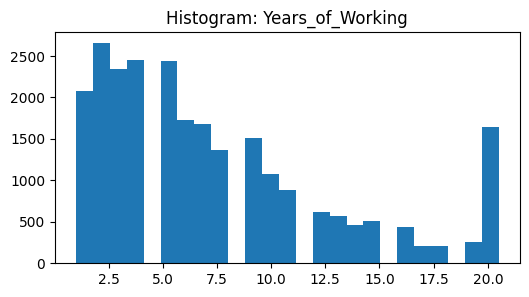

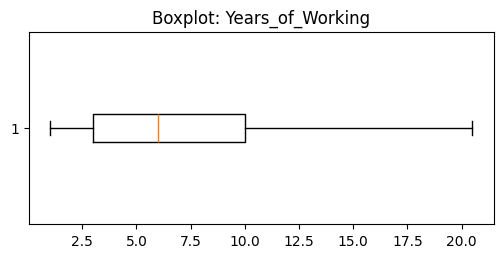

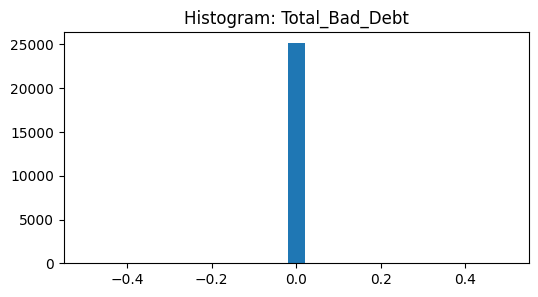

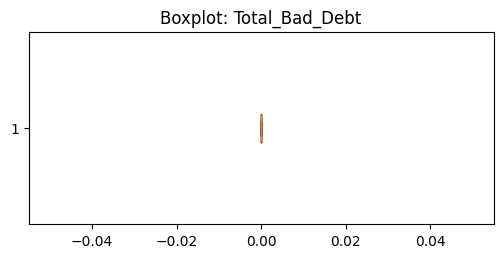

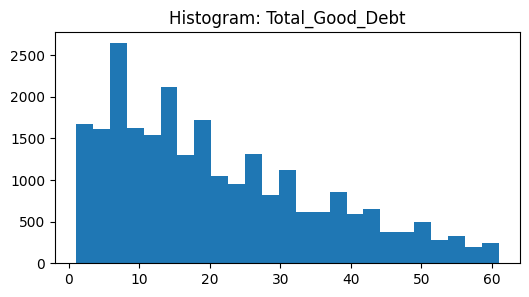

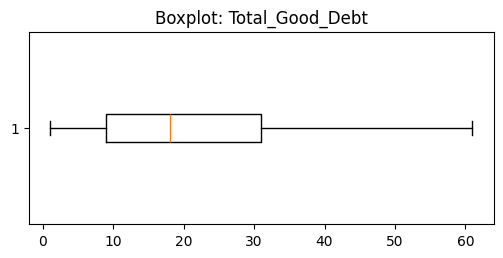

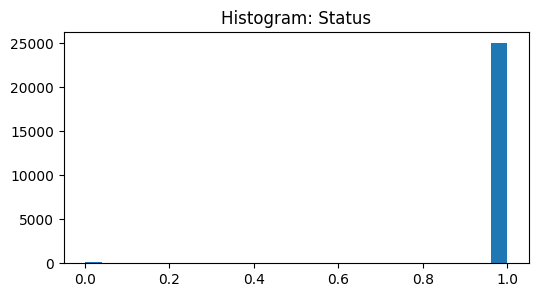

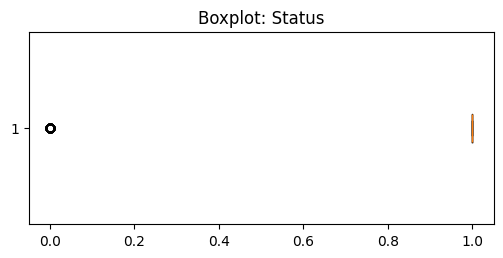

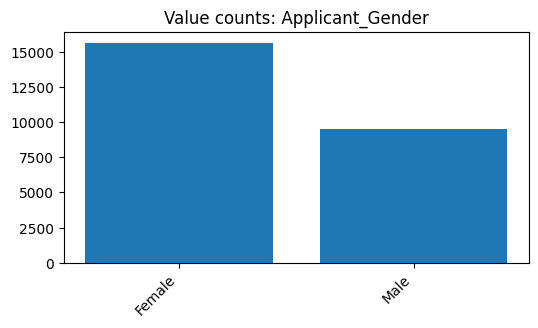

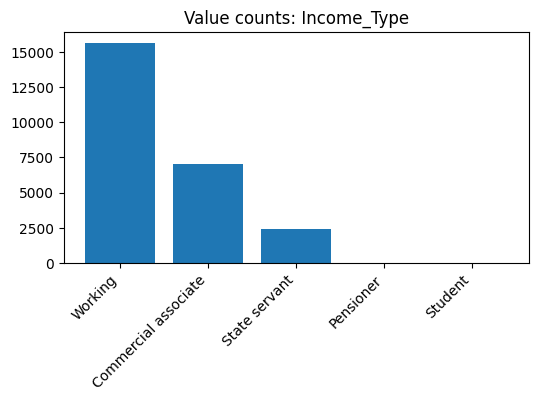

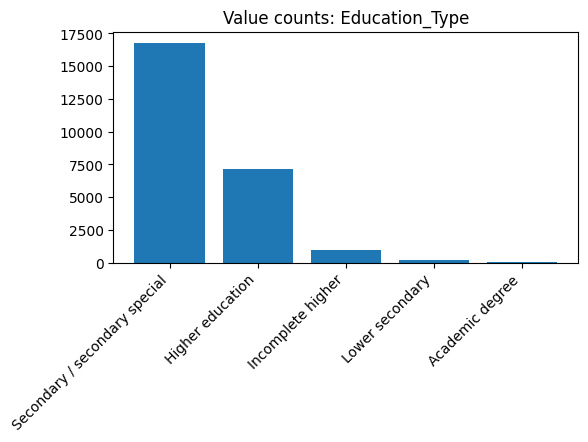

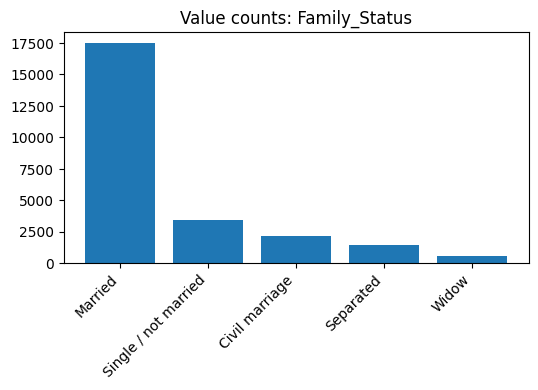

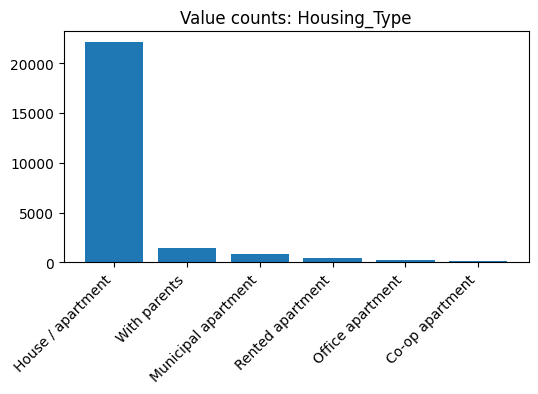

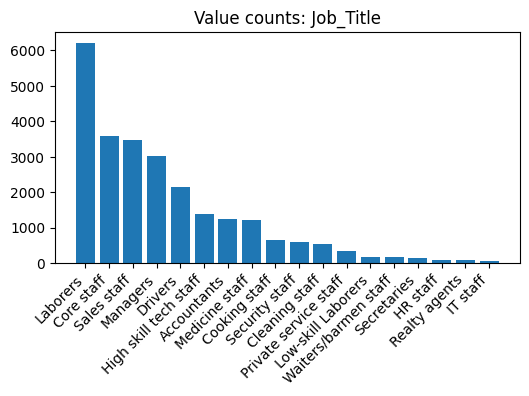

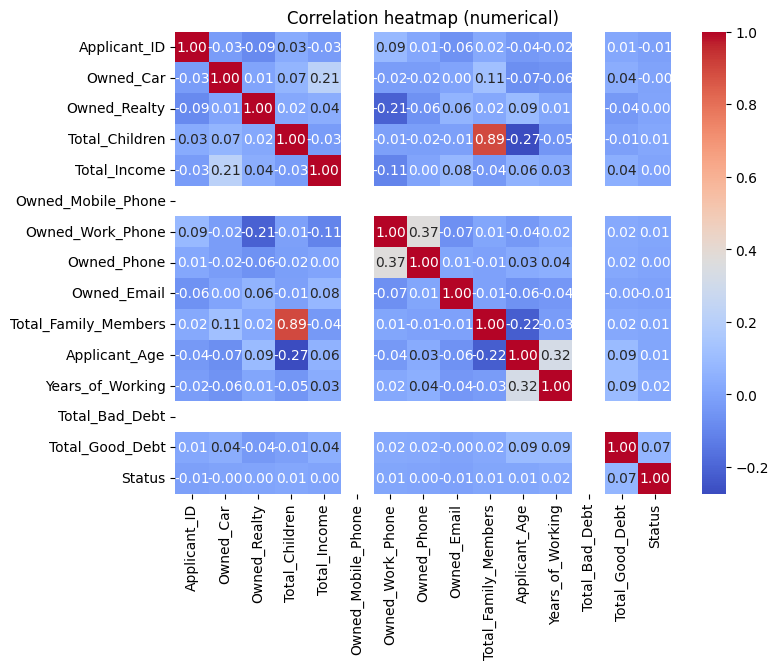

In [46]:
# Helper save
import os
# def save_plot(fig, name):
#     path = os.path.join("outputs/plots", name)
#     fig.savefig(path, bbox_inches='tight')
#     plt.close(fig)
#     print("saved:", path)

# Univariate: histograms & boxplots for numeric features
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols:
    # fig, ax = 
    plt.subplots(figsize=(6,3))
    plt.hist(df_clean[c].dropna(), bins=25)
    plt.title(f"Histogram: {c}")
    # save_plot(fig, f"hist_{c}.png")

    # fig, ax = 
    plt.subplots(figsize=(6,2.5))
    plt.boxplot(df_clean[c].dropna(), vert=False)
    plt.title(f"Boxplot: {c}")
    # save_plot(fig, f"box_{c}.png")

# Categorical bar plots (top categories)
cat_cols = [c for c in df_clean.columns if df_clean[c].dtype == 'object' or df_clean[c].dtype.name == 'category']
for c in cat_cols:
    vc = df_clean[c].value_counts().nlargest(20)
    # fig, ax = plt.
    plt.subplots(figsize=(6,3))
    plt.bar(vc.index.astype(str), vc.values)
    plt.title(f"Value counts: {c}")
    plt.xticks(vc.index.astype(str), rotation=45, ha='right')
    # save_plot(fig, f"bar_{c}.png")

# Bivariate: approval rate by gender (if available)
if 'eligibility' in df_clean.columns and 'gender' in df_clean.columns:
    grp = df_clean.groupby('gender')['eligibility'].agg(['count','mean']).reset_index().rename(columns={'mean':'approval_rate'})
    # fig, ax = 
    plt.subplots(figsize=(5,3))
    plt.bar(grp['gender'], grp['approval_rate'])
    plt.ylim(0,1)
    plt.ylabel('Approval rate')
    plt.title('Approval Rate by Gender')
    # save_plot(fig, "approval_by_gender.png")

# Correlation heatmap (numerical)
if len(num_cols) >= 2:
    corr = df_clean[num_cols].corr()
    # fig, ax = 
    plt.subplots(figsize=(8,6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
    plt.title("Correlation heatmap (numerical)")
    plt.title("Correlation heatmap (numerical)")
    plt.show()
    # save_plot(fig, "correlation_heatmap.png")



C:\Users\abdul\AppData\Local\Temp\ipykernel_22752\2362159130.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.subplots(figsize=(6,3))


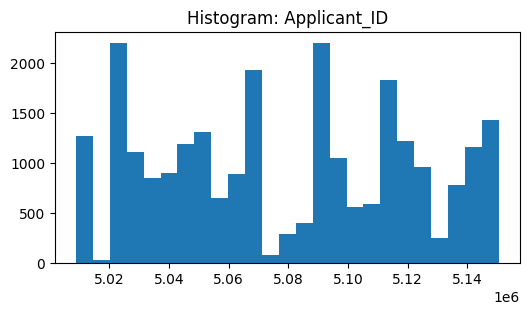

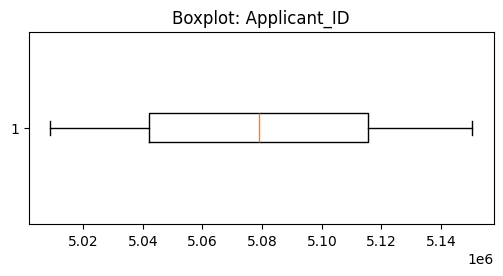

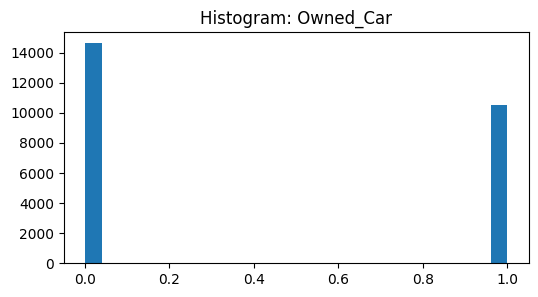

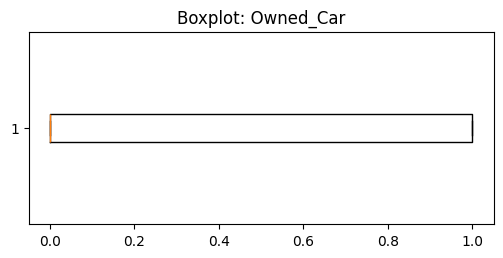

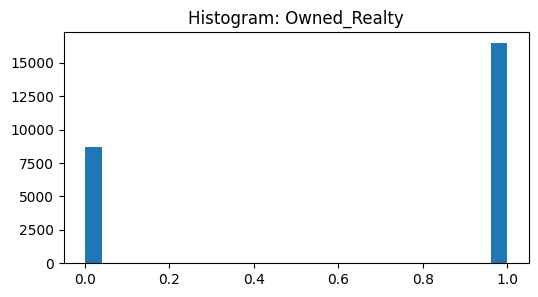

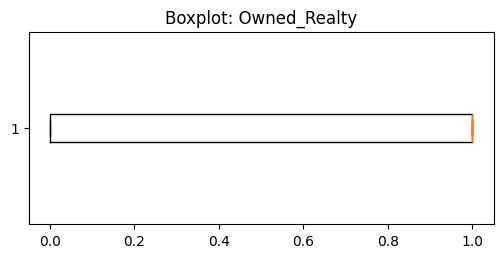

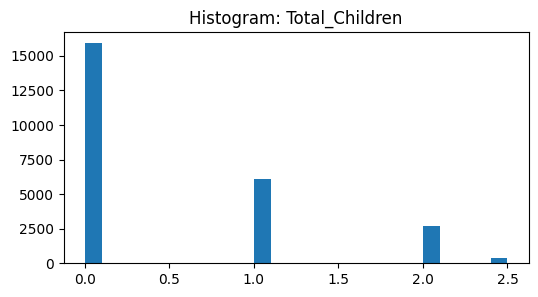

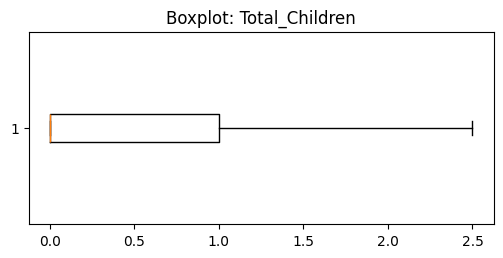

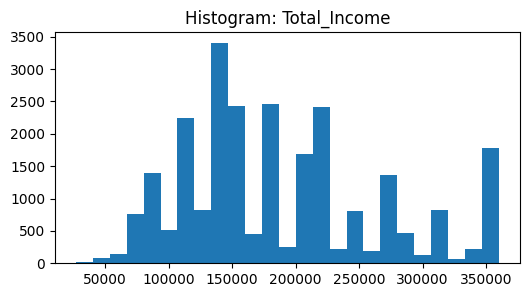

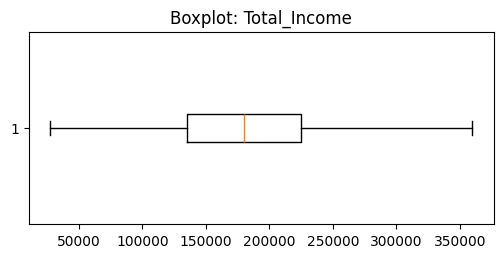

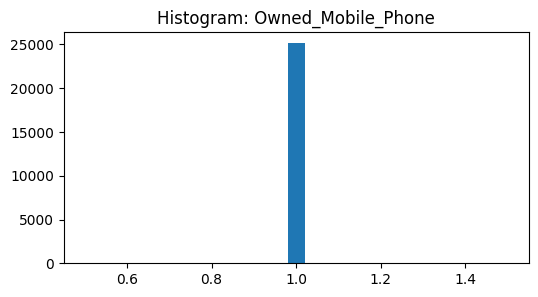

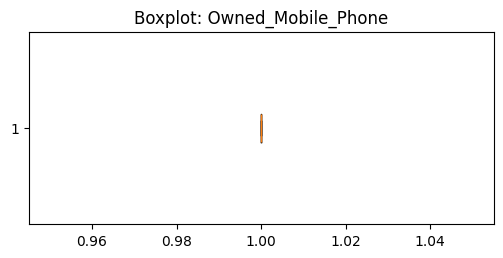

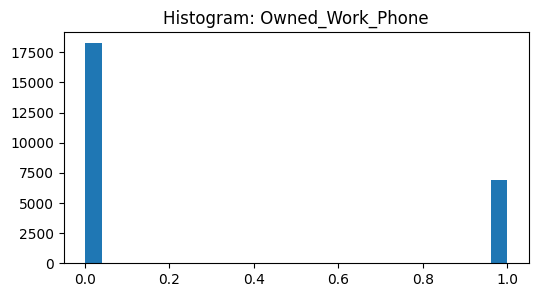

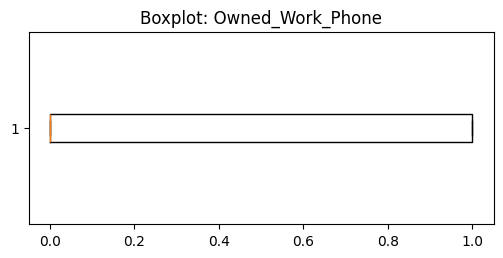

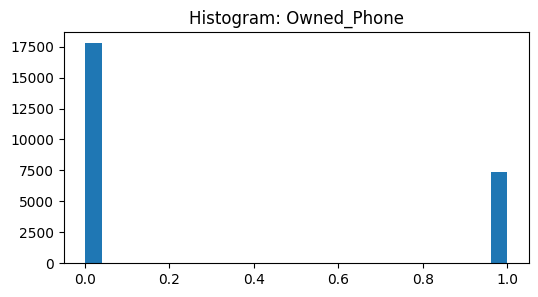

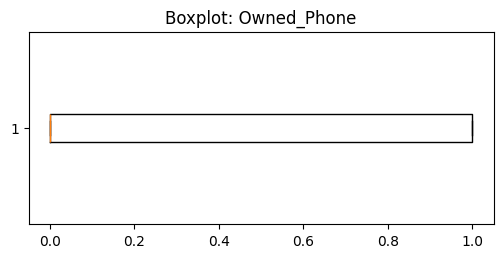

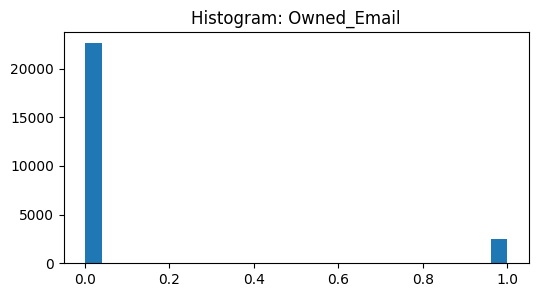

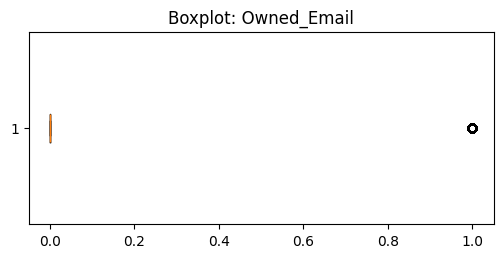

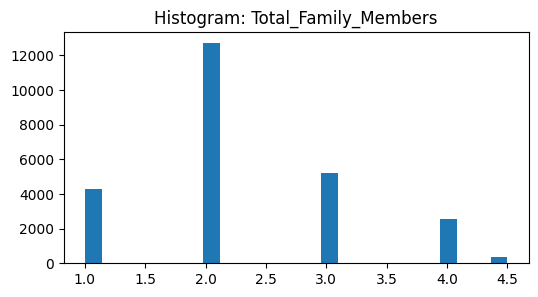

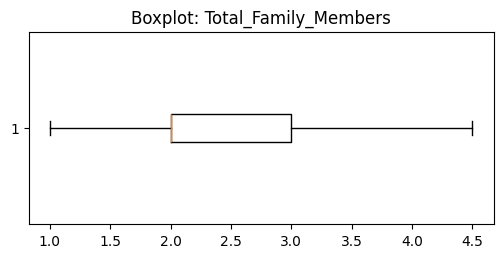

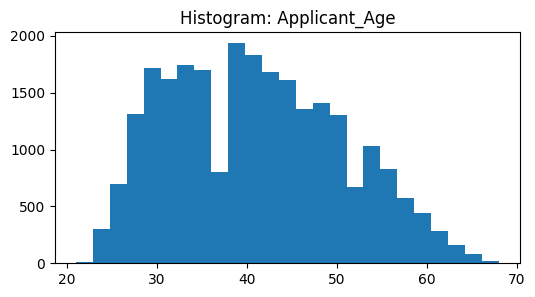

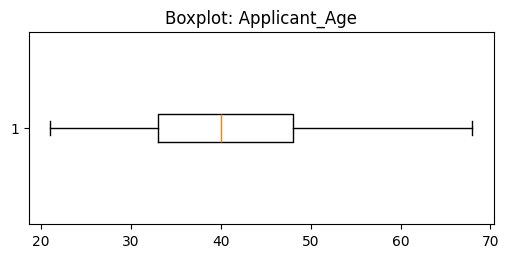

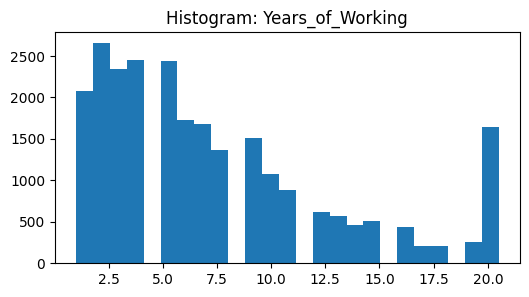

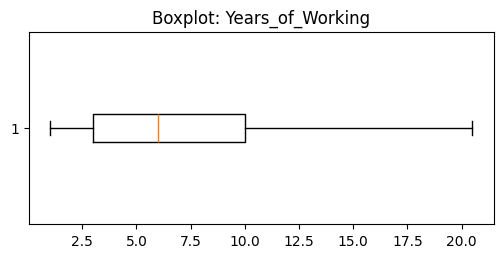

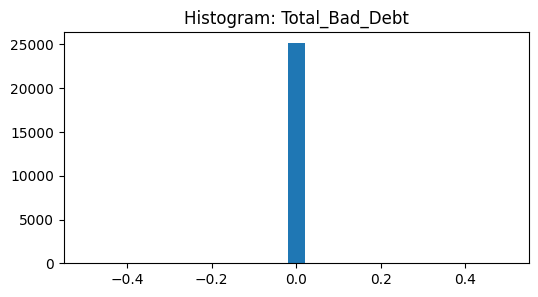

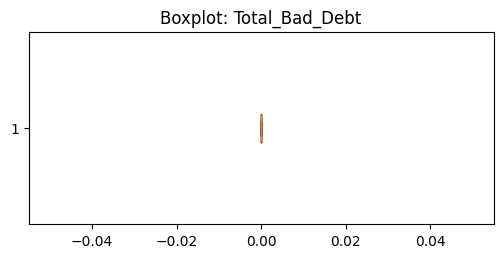

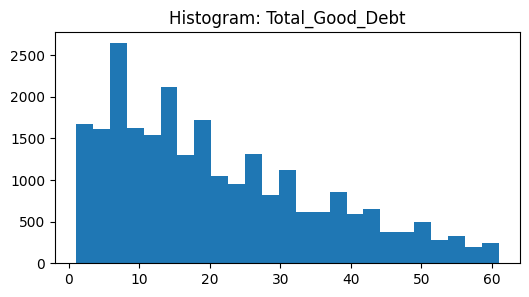

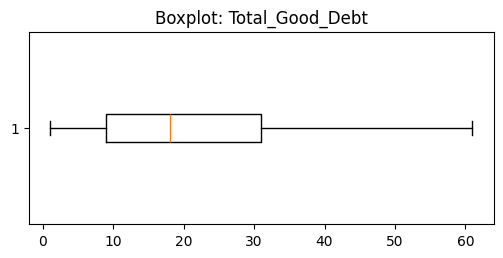

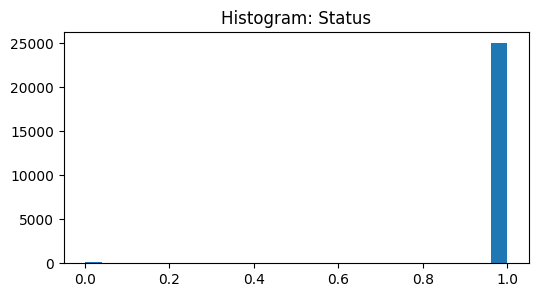

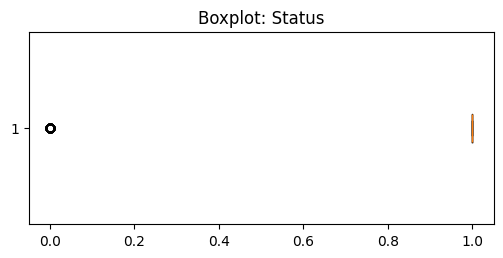

In [47]:
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols:
    # fig, ax = 
    plt.subplots(figsize=(6,3))
    plt.hist(df_clean[c].dropna(), bins=25)
    plt.title(f"Histogram: {c}")
    # save_plot(fig, f"hist_{c}.png")

    # fig, ax = 
    plt.subplots(figsize=(6,2.5))
    plt.boxplot(df_clean[c].dropna(), vert=False)
    plt.title(f"Boxplot: {c}")

C:\Users\abdul\AppData\Local\Temp\ipykernel_22752\3486700425.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=approved, x=col, palette='viridis')


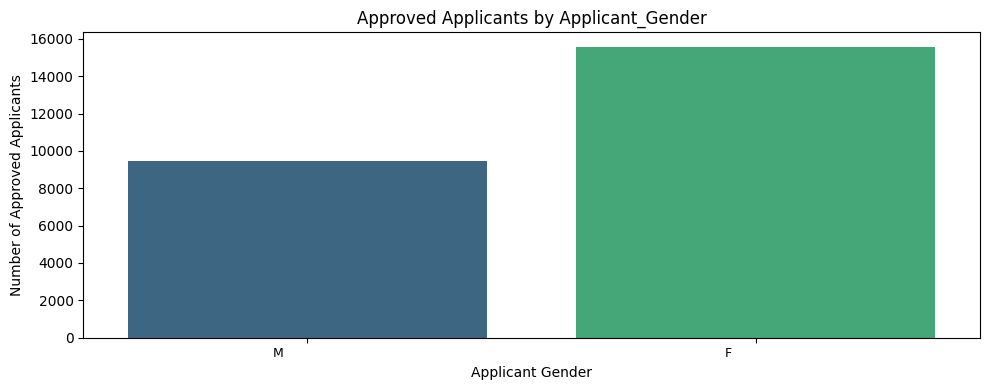

C:\Users\abdul\AppData\Local\Temp\ipykernel_22752\3486700425.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=approved, x=col, palette='viridis')


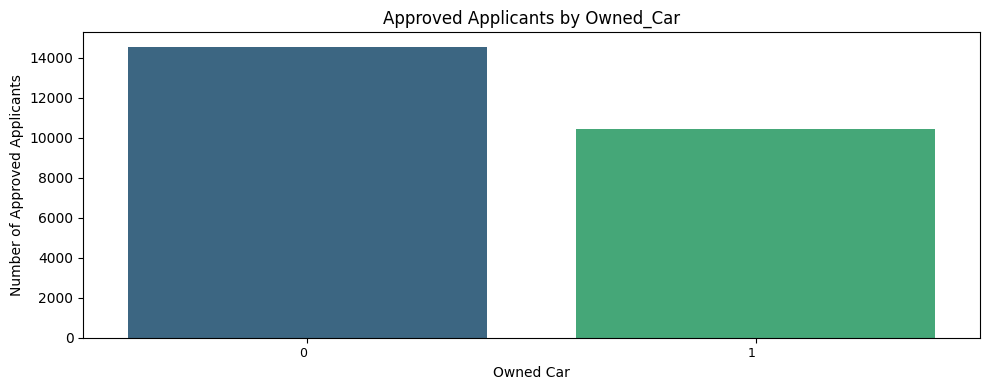

C:\Users\abdul\AppData\Local\Temp\ipykernel_22752\3486700425.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=approved, x=col, palette='viridis')


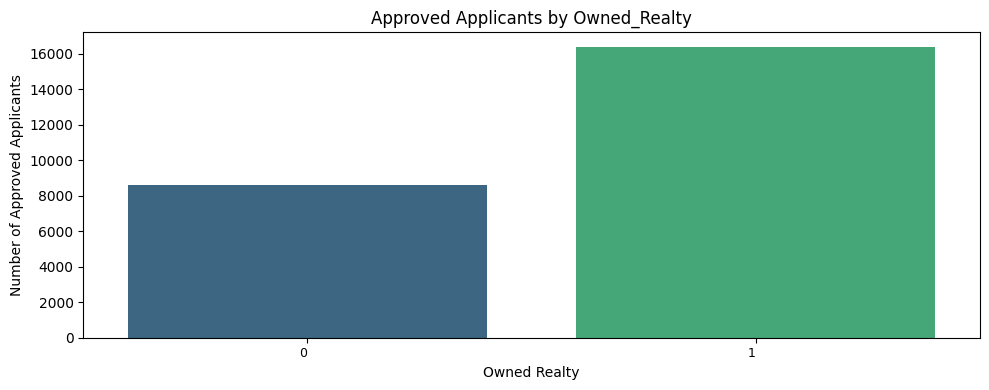

C:\Users\abdul\AppData\Local\Temp\ipykernel_22752\3486700425.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=approved, x=col, palette='viridis')


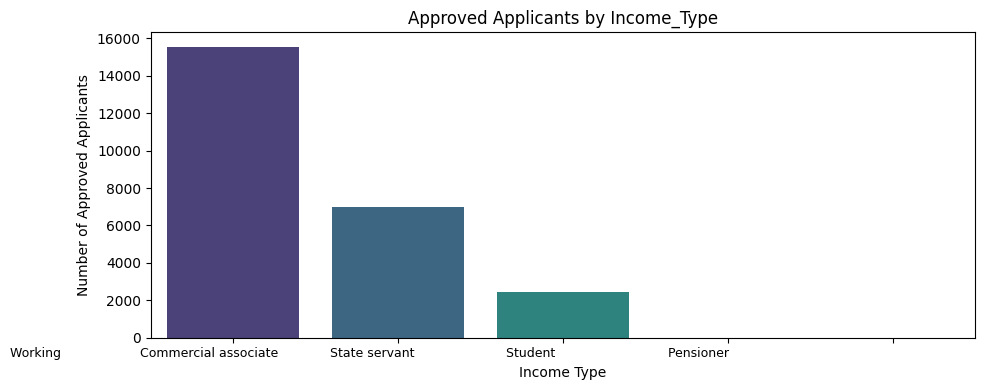

C:\Users\abdul\AppData\Local\Temp\ipykernel_22752\3486700425.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=approved, x=col, palette='viridis')


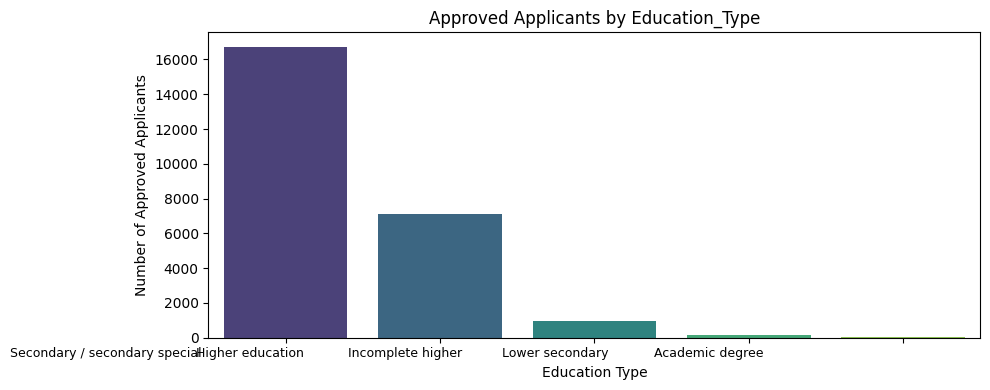

C:\Users\abdul\AppData\Local\Temp\ipykernel_22752\3486700425.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=approved, x=col, palette='viridis')


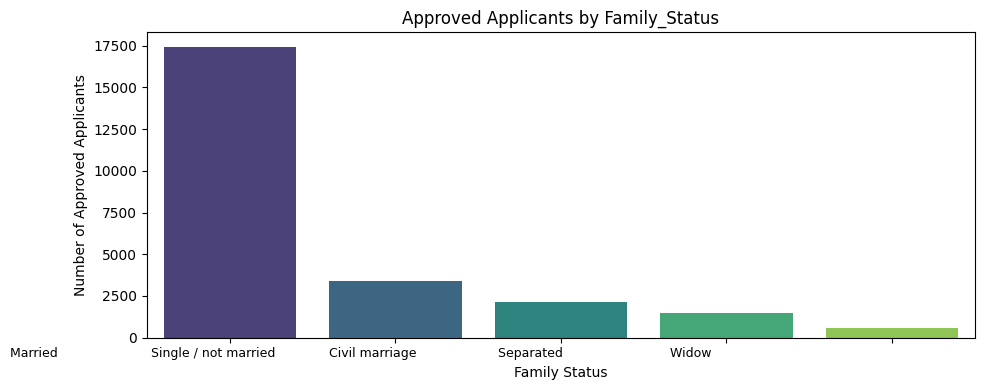

C:\Users\abdul\AppData\Local\Temp\ipykernel_22752\3486700425.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=approved, x=col, palette='viridis')


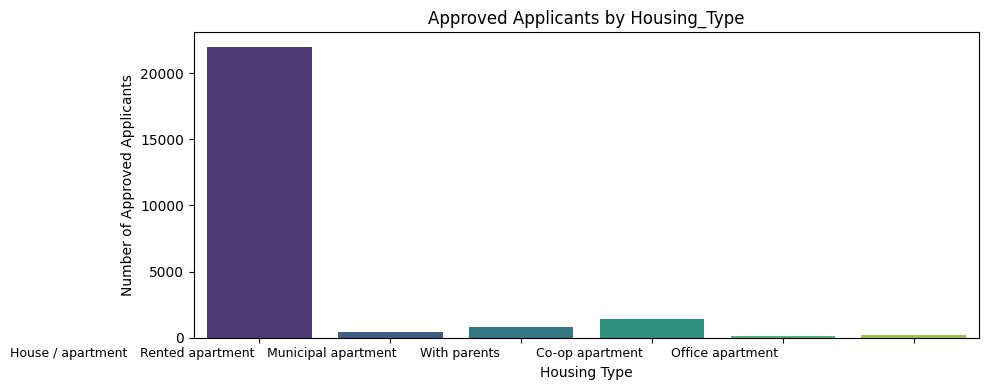

C:\Users\abdul\AppData\Local\Temp\ipykernel_22752\3486700425.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=approved, x=col, palette='viridis')


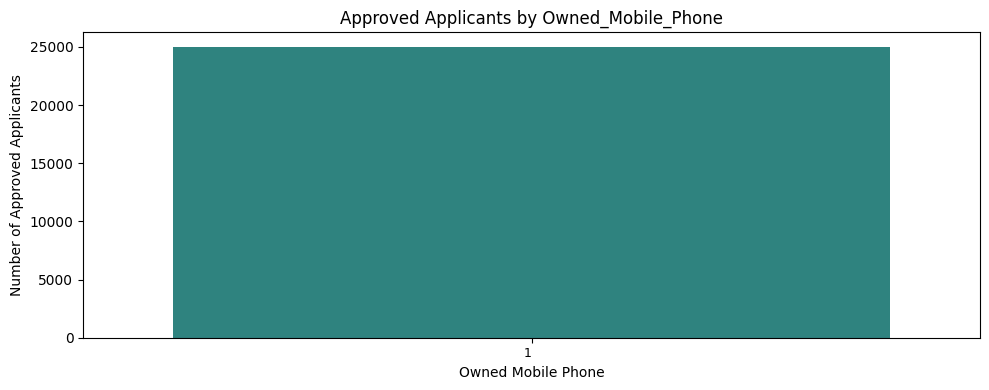

C:\Users\abdul\AppData\Local\Temp\ipykernel_22752\3486700425.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=approved, x=col, palette='viridis')


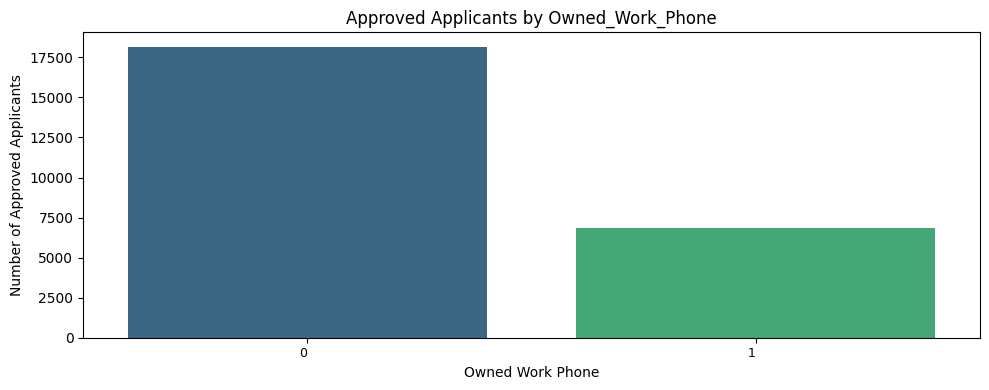

C:\Users\abdul\AppData\Local\Temp\ipykernel_22752\3486700425.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=approved, x=col, palette='viridis')


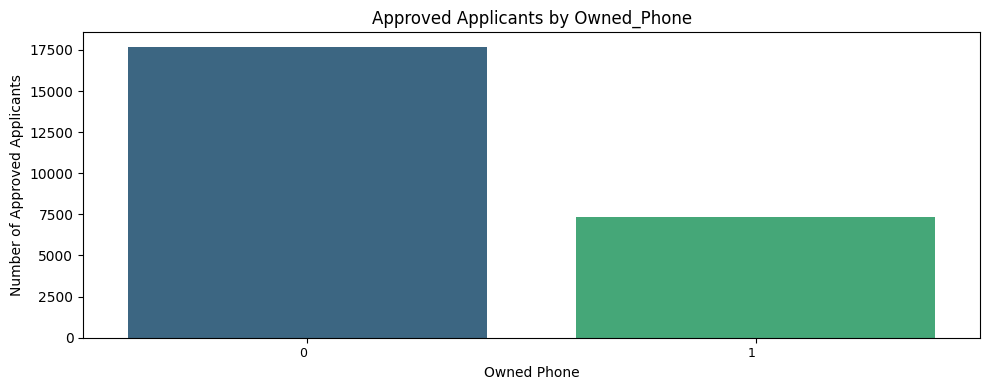

C:\Users\abdul\AppData\Local\Temp\ipykernel_22752\3486700425.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=approved, x=col, palette='viridis')


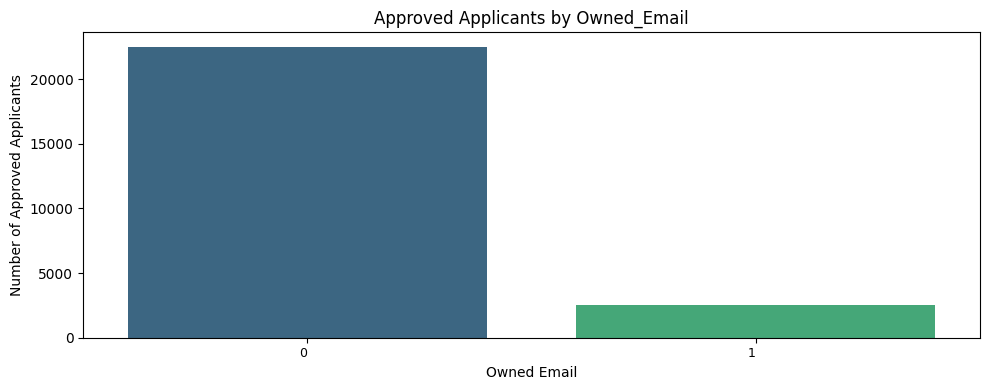

C:\Users\abdul\AppData\Local\Temp\ipykernel_22752\3486700425.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=approved, x=col, palette='viridis')


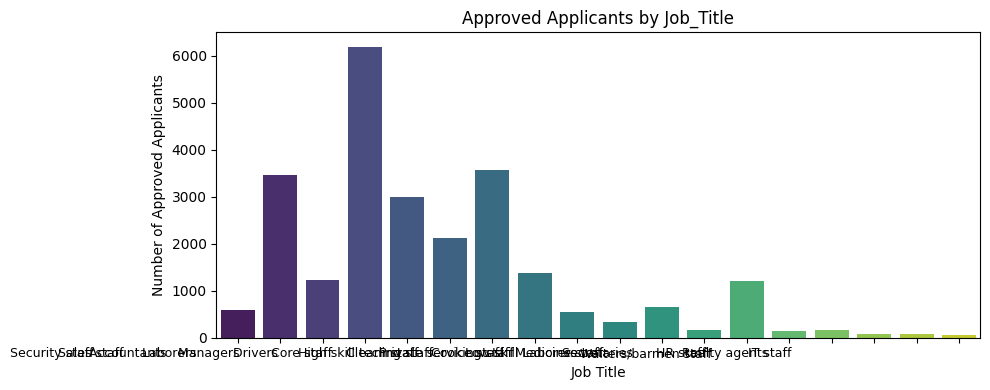

In [69]:
approved = df[df['Status'] == 1]

# List of categorical columns to analyze
cat_cols = [
    'Applicant_Gender', 'Owned_Car', 'Owned_Realty', 
    'Income_Type', 'Education_Type', 'Family_Status', 
    'Housing_Type', 'Owned_Mobile_Phone', 'Owned_Work_Phone', 
    'Owned_Phone', 'Owned_Email', 'Job_Title'
]

# Loop through and plot approved counts by category
for col in cat_cols:
    plt.figure(figsize=(10,4))
    sns.countplot(data=approved, x=col, palette='viridis')
    plt.title(f'Approved Applicants by {col}')
    plt.xlabel(col.replace('_', ' '))
    plt.ylabel('Number of Approved Applicants')
    plt.xticks( ha='right',fontsize=9)
    plt.tight_layout()
    plt.show()

C:\Users\abdul\AppData\Local\Temp\ipykernel_22752\1683676849.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=approved, x=col, order=order, palette='viridis')


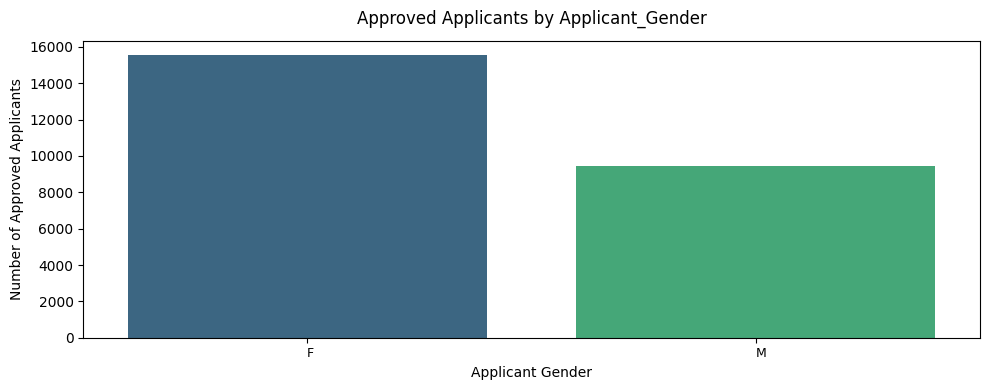

C:\Users\abdul\AppData\Local\Temp\ipykernel_22752\1683676849.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=approved, x=col, order=order, palette='viridis')


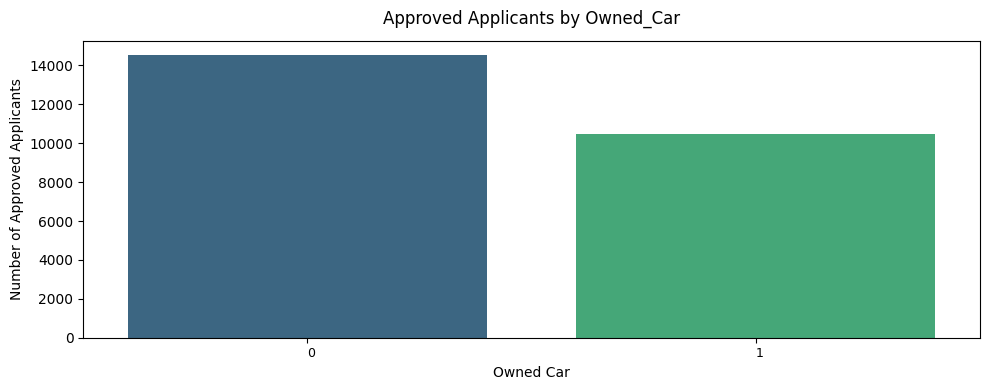

C:\Users\abdul\AppData\Local\Temp\ipykernel_22752\1683676849.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=approved, x=col, order=order, palette='viridis')


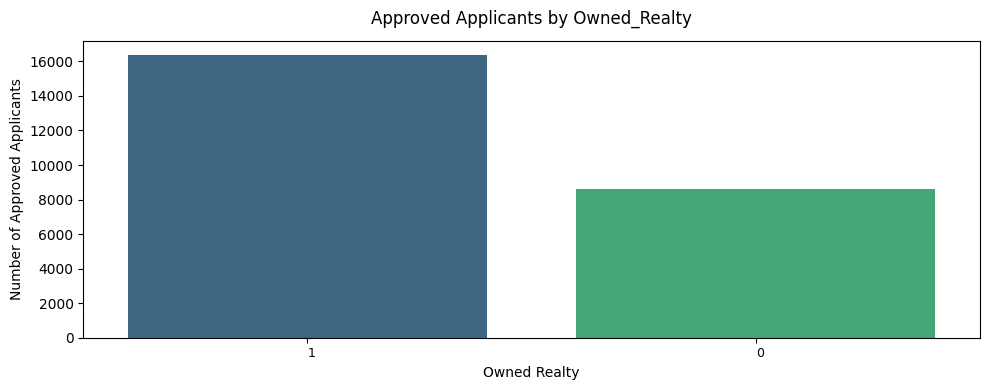

C:\Users\abdul\AppData\Local\Temp\ipykernel_22752\1683676849.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=approved, x=col, order=order, palette='viridis')


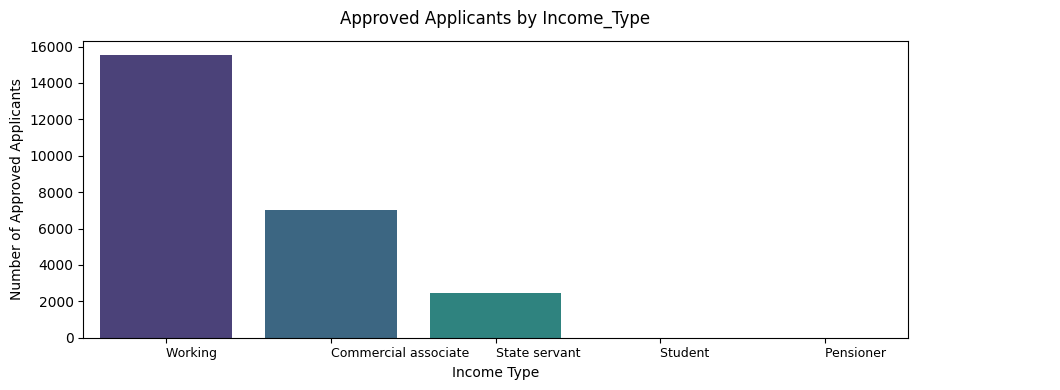

C:\Users\abdul\AppData\Local\Temp\ipykernel_22752\1683676849.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=approved, x=col, order=order, palette='viridis')


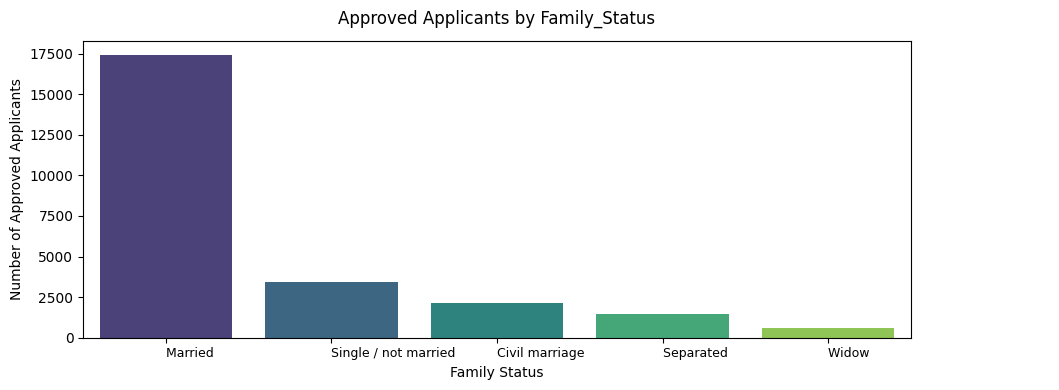

C:\Users\abdul\AppData\Local\Temp\ipykernel_22752\1683676849.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=approved, x=col, order=order, palette='viridis')


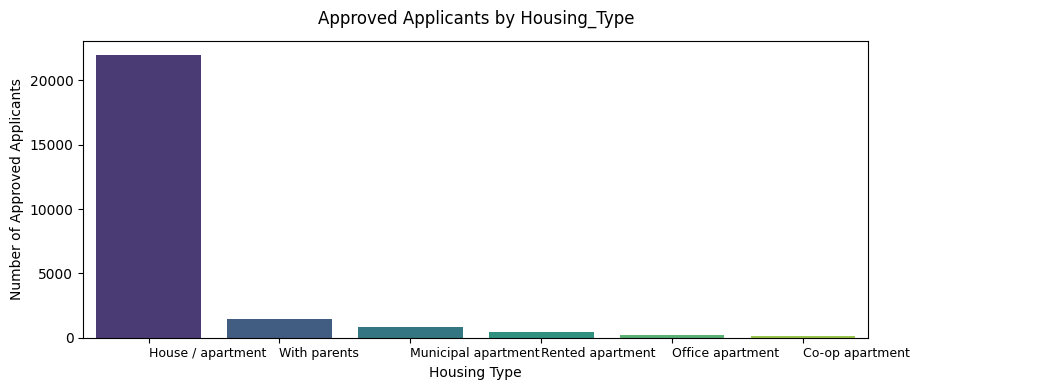

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt


# Filter only approved applicants
approved = df[df['Status'] == 1]

# List of categorical columns
cat_cols = [
    'Applicant_Gender', 'Owned_Car', 'Owned_Realty', 
    'Income_Type', 'Family_Status', 'Housing_Type'
]

# Loop through and plot
for col in cat_cols:
    plt.figure(figsize=(10,4))
    
    # Sort categories by frequency to keep bars in logical order
    order = approved[col].value_counts().index
    
    ax = sns.countplot(data=approved, x=col, order=order, palette='viridis')
    
    plt.title(f'Approved Applicants by {col}', fontsize=12, pad=12)
    plt.xlabel(col.replace('_', ' '), fontsize=10)
    plt.ylabel('Number of Approved Applicants', fontsize=10)
    
    # Rotate and align x-labels properly
    plt.xticks(ha='right', fontsize=9)
    
    # Adjust layout to avoid overlap
    plt.tight_layout()
    
    # Align tick labels with bars visually
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('left')
    
    # Save and show
    plt.show()


C:\Users\abdul\AppData\Local\Temp\ipykernel_22752\2951632536.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=approved, x=col, order=order, palette='viridis')


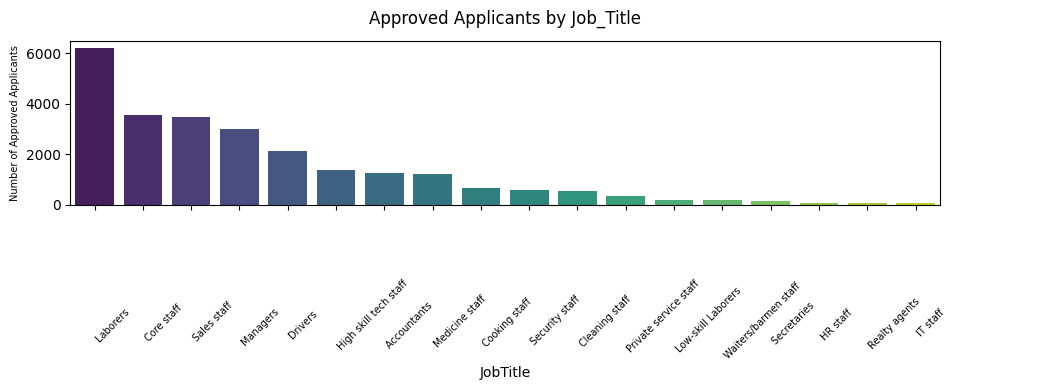

In [86]:
approved = df[df['Status'] == 1]
col='Job_Title'
plt.figure(figsize=(10,4))  
order = approved[col].value_counts().index
ax = sns.countplot(data=approved, x=col, order=order, palette='viridis')
plt.title(f'Approved Applicants by {col}', fontsize=12, pad=12)
plt.xlabel(col.replace('_', ''), fontsize=10)
plt.ylabel('Number of Approved Applicants', fontsize=7)
    
    # Rotate and align x-labels properly
plt.xticks(rotation=45, fontsize=7)
    
    # Adjust layout to avoid overlap
plt.tight_layout()
    
    # Align tick labels with bars visually
for label in ax.get_xticklabels():
    label.set_horizontalalignment('left')
    
    # Save and show
plt.show()